# Modeling

## tl;dr
Preliminary within-core estimates and held-out franchise contrasts are shown below. Read uncertainty and sensitivity before interpreting the hypothesis.

## Context & Methods
Possession-weighted linear regression; core fixed effects; lagged fifth quality and five skill main effects. 24 franchise clusters in the primary sample; all lineup representations remain together in holdout validation.

### Key Assumptions
Regular-season PBP Stats aggregates; lagged profiles; observational comparisons. See [methodology](../docs/methodology_notes.md).

## Data
Run the cached pipeline and offline analysis before this notebook. No network requests are made here.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import display, Image, Markdown
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'data_pipeline.py').exists())
DATA = ROOT / 'data' / 'processed'
import sys
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
pd.set_option('display.max_columns', 12)


## Results

### Primary and threshold estimates

,threshold,coefficient,ci_low,ci_high,p_value,rows,cores,lineups,within_r2
12,25,-6.3188,-22.6520,10.0144,0.4348,2558,978,787,0.0074
39,50,2.0783,-19.8727,24.0292,0.8464,1018,430,358,0.0089
66,100,-6.7620,-34.4022,20.8782,0.6162,320,143,142,0.0353


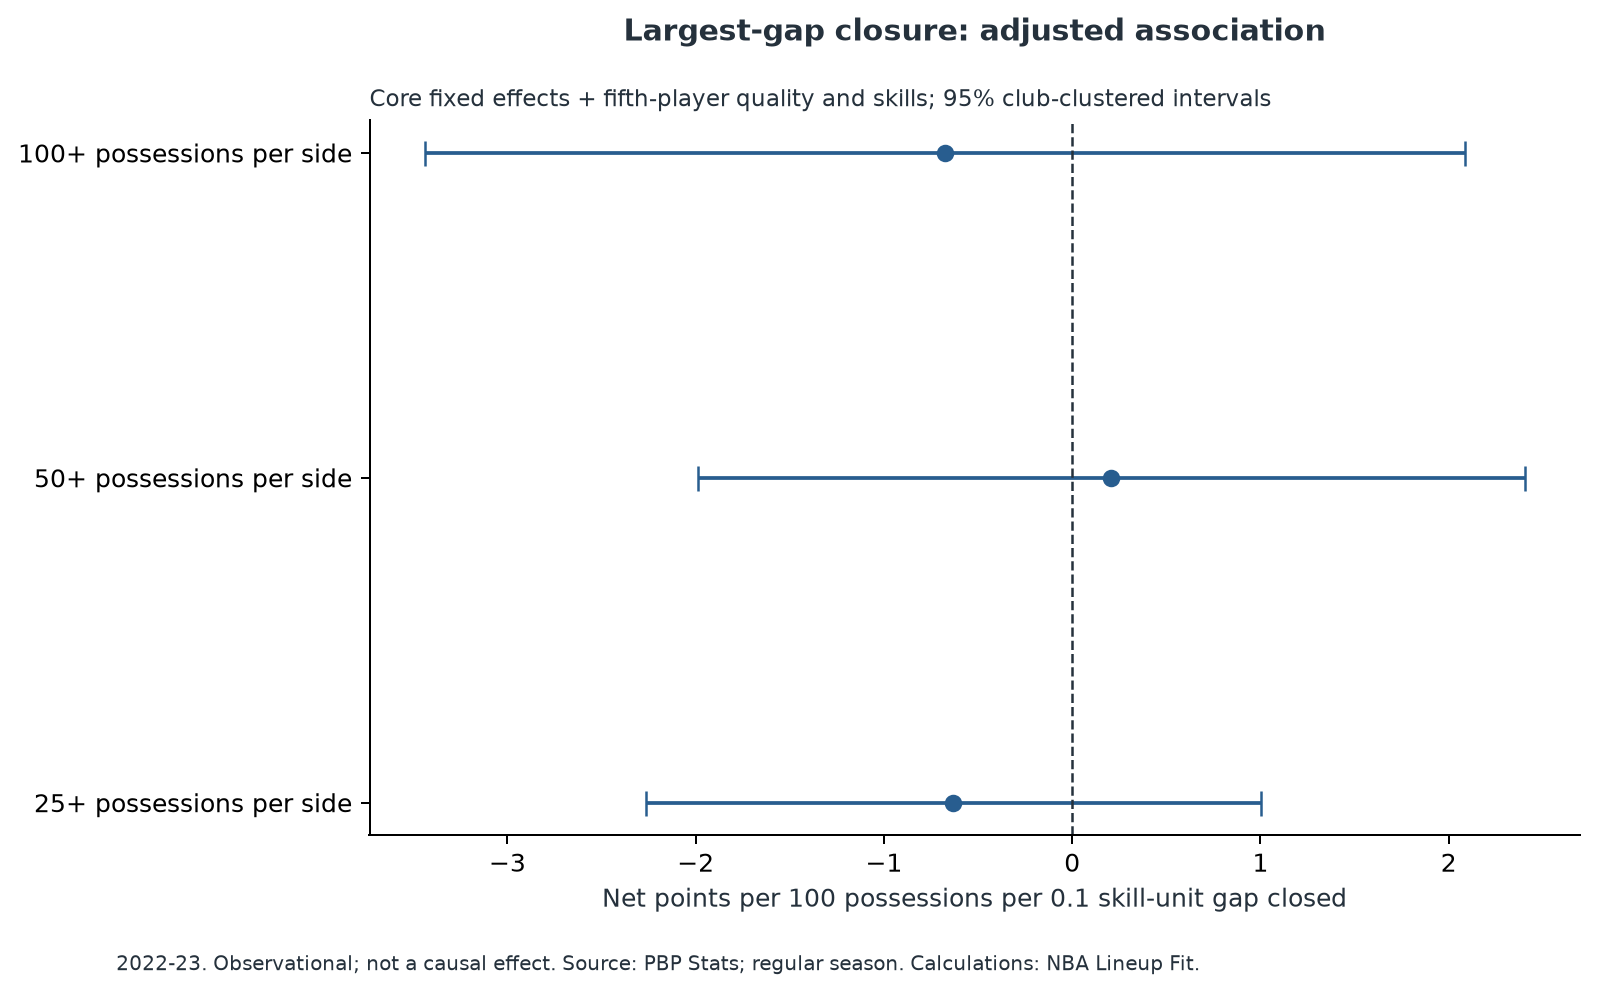

In [2]:
coef=pd.read_csv(DATA/'model_coefficients.csv')
primary=coef[(coef.term=='complementarity') & coef.weighted & coef.skill_controls]
display(primary[['threshold','coefficient','ci_low','ci_high','p_value','rows','cores','lineups','within_r2']].round(4))
display(Image(filename=str(ROOT/'figures'/'model_effects.png')))

### Full specification sensitivity

In [3]:
display(coef[coef.term==coef.fit_column][['threshold','fit_column','weighted','skill_controls','coefficient','ci_low','ci_high','p_value']].round(4))

,threshold,fit_column,weighted,skill_controls,coefficient,ci_low,ci_high,p_value
12,25,complementarity,True,True,-6.3188,-22.6520,10.0144,0.4348
19,25,complementarity_all,True,True,-33.0802,-95.4804,29.3200,0.2868
26,25,complementarity_uncapped,True,True,-1.9586,-6.6137,2.6966,0.3961
39,50,complementarity,True,True,2.0783,-19.8727,24.0292,0.8464
46,50,complementarity_all,True,True,-10.1039,-94.0998,73.8919,0.8057
53,50,complementarity_uncapped,True,True,1.4666,-4.5658,7.4990,0.6198
66,100,complementarity,True,True,-6.7620,-34.4022,20.8782,0.6162
73,100,complementarity_all,True,True,-62.6011,-169.9223,44.7200,0.2386
80,100,complementarity_uncapped,True,True,-2.3183,-12.4296,7.7930,0.6384
87,50,complementarity,False,True,5.7892,-16.5022,28.0806,0.5963


### Holdout contrasts

In [4]:
cv=pd.read_csv(DATA/'heldout_club_validation.csv')
display(cv.groupby('model')[['squared_error_sum','weight_sum']].sum().assign(rmse=lambda x:np.sqrt(x.squared_error_sum/x.weight_sum)))
print('Test outcomes are demeaned within core only to score contrasts; this is not prospective absolute-rating prediction.')

Test outcomes are demeaned within core only to score contrasts; this is not prospective absolute-rating prediction.


,squared_error_sum,weight_sum,rmse
model,,,
plus_complementarity,6.281768e+06,54956.5,10.691322
talent_and_skills,6.243141e+06,54956.5,10.658401


## Takeaways
An adjusted association does not show that replacing a player would cause improvement. Residual talent error, lineup selection, opponent strength, and defensive measurement remain limitations. Null estimates or weaker alternative specifications must remain visible.